# YOLO 기반 사람 감지 + 사람 수 카운팅 + 임시 위험도 계산

이 노트북은 ROS2 패키지로 만들기 전에, **카메라 이미지에서 사람만 감지할 수 있는지**를 먼저 검증하기 위한 최소 실험용 노트북이다.

## 목표

```text
입력 이미지 / 웹캠 프레임
    ↓
YOLO pretrained detector
    ↓
person class만 필터링
    ↓
사람 수 count
    ↓
bbox, confidence, bbox area ratio 계산
    ↓
임시 person risk score 계산
```

## 출력

- 사람 수
- 사람 감지 여부
- 사람 bbox 좌표
- bbox confidence
- 가장 큰 사람 bbox 면적 비율
- rule-based person risk score
- 시각화 이미지

## 1. 설치

아래 셀은 필요한 패키지를 설치한다.

이미 ROS2용 venv를 쓰고 있다면 터미널에서 먼저 다음처럼 실행한 뒤 Jupyter를 켜는 편이 낫다.

```zsh
source /opt/ros/jazzy/setup.zsh
source ~/venv/ros2/bin/activate
pip install ultralytics opencv-python matplotlib pandas ipywidgets
jupyter notebook
```

Jupyter 안에서 바로 설치하려면 아래 셀을 실행한다.

In [8]:
# 필요할 때만 실행
# !pip install -U ultralytics opencv-python matplotlib pandas ipywidgets

## 2. import 및 환경 확인

In [9]:
import os
import math
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("CUDA device:", torch.cuda.get_device_name(0))
except Exception as e:
    print("torch check failed:", e)

OpenCV: 4.13.0
NumPy: 2.4.6
PyTorch: 2.12.0+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4070 SUPER


## 3. 설정값

COCO pretrained YOLO에서 `person` class id는 `0`이다.

```python
classes=[0]
```

를 사용하면 사람만 탐지한다.

In [10]:
# =========================
# 기본 설정
# =========================

MODEL_PATH = "yolo11n.pt"   # 가볍고 빠름. 안 되면 "yolov8n.pt"로 바꿔도 됨.
PERSON_CLASS_ID = 0         # COCO person class

CONF_THRESHOLD = 0.35
IOU_THRESHOLD = 0.45
IMGSZ = 640

# CPU면 "cpu", CUDA 가능하면 0
DEVICE = 0 if "torch" in globals() and torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

DEVICE: 0


## 4. YOLO 모델 로드

처음 실행하면 `yolo11n.pt`가 자동 다운로드될 수 있다.

In [11]:
model = YOLO(MODEL_PATH)
print("Loaded:", MODEL_PATH)

Loaded: yolo11n.pt


## 5. 위험도 계산 함수

여기서는 학습된 위험도 모델이 아니라, 사람 감지 결과에서 계산한 **임시 rule-based 위험도**를 사용한다.

사람 수 기반 위험도:

\[
R_{person} = 1 - e^{-kN}
\]

bbox 크기 기반 근접도:

\[
R_{prox} = \min(g \cdot A_{max}, 1)
\]

최종 위험도:

\[
R = w_p R_{person} + w_z R_{prox}
\]

- \(N\): 사람 수
- \(A_{max}\): 가장 큰 사람 bbox 면적 / 전체 이미지 면적
- bbox가 클수록 카메라에 가까운 것으로 가정

In [12]:
def compute_person_risk(
    person_count: int,
    largest_area_ratio: float,
    person_risk_k: float = 0.45,
    proximity_gain: float = 3.0,
    risk_person_weight: float = 0.70,
    risk_proximity_weight: float = 0.30,
) -> float:
    """
    사람 수와 가장 큰 bbox 면적 비율로 임시 위험도 계산.

    person_count == 0이면 risk = 0.0
    person_count가 증가하면 R_person은 saturation 형태로 증가.
    bbox area ratio가 클수록 가까운 사람으로 보고 위험도 증가.
    """
    if person_count <= 0:
        return 0.0

    r_person = 1.0 - math.exp(-person_risk_k * float(person_count))
    r_proximity = min(proximity_gain * float(largest_area_ratio), 1.0)

    risk = (
        risk_person_weight * r_person
        + risk_proximity_weight * r_proximity
    )

    return float(max(0.0, min(1.0, risk)))

## 6. 사람 감지 함수

이 함수가 핵심이다.

입력:
- BGR 이미지(OpenCV 형식)

출력:
- `person_count`
- `detected`
- `risk`
- `boxes`
- `annotated`

In [13]:
def detect_people_bgr(
    frame_bgr: np.ndarray,
    model,
    conf_threshold: float = CONF_THRESHOLD,
    iou_threshold: float = IOU_THRESHOLD,
    imgsz: int = IMGSZ,
    device = DEVICE,
):
    """
    BGR 이미지에서 사람만 탐지한다.

    boxes format:
    [
        {
            "x1": float,
            "y1": float,
            "x2": float,
            "y2": float,
            "conf": float,
            "area_ratio": float,
            "cx": float,
            "cy": float,
        },
        ...
    ]
    """
    if frame_bgr is None or frame_bgr.size == 0:
        raise ValueError("empty frame")

    img_h, img_w = frame_bgr.shape[:2]
    img_area = float(max(img_h * img_w, 1))

    results = model.predict(
        source=frame_bgr,
        conf=conf_threshold,
        iou=iou_threshold,
        classes=[PERSON_CLASS_ID],  # person only
        imgsz=imgsz,
        device=device,
        verbose=False,
    )

    result = results[0]
    boxes = []
    largest_area_ratio = 0.0

    if result.boxes is not None:
        for box in result.boxes:
            xyxy = box.xyxy[0].detach().cpu().numpy().astype(float)
            conf = float(box.conf[0].detach().cpu().item())

            x1, y1, x2, y2 = xyxy.tolist()

            # clamp
            x1 = max(0.0, min(float(img_w - 1), x1))
            y1 = max(0.0, min(float(img_h - 1), y1))
            x2 = max(0.0, min(float(img_w - 1), x2))
            y2 = max(0.0, min(float(img_h - 1), y2))

            w = max(0.0, x2 - x1)
            h = max(0.0, y2 - y1)
            area_ratio = float((w * h) / img_area)
            largest_area_ratio = max(largest_area_ratio, area_ratio)

            boxes.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "conf": conf,
                "area_ratio": area_ratio,
                "cx": (x1 + x2) / 2.0,
                "cy": (y1 + y2) / 2.0,
            })

    person_count = len(boxes)
    risk = compute_person_risk(person_count, largest_area_ratio)

    annotated = result.plot()

    # status overlay
    text = f"persons={person_count} risk={risk:.2f}"
    cv2.rectangle(annotated, (10, 10), (360, 55), (0, 0, 0), -1)
    cv2.putText(
        annotated,
        text,
        (20, 42),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

    return {
        "person_count": person_count,
        "detected": person_count > 0,
        "risk": risk,
        "largest_area_ratio": largest_area_ratio,
        "boxes": boxes,
        "annotated": annotated,
    }


def show_bgr(image_bgr, figsize=(10, 7), title=None):
    """OpenCV BGR 이미지를 Jupyter에서 표시."""
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(image_rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 7. 이미지 1장 테스트

`IMAGE_PATH`를 네 이미지 경로로 바꿔서 실행한다.

예:

```python
IMAGE_PATH = "/home/bomin/Desktop/test.jpg"
```

person_count: 0
detected: False
risk: 0.0
largest_area_ratio: 0.0
boxes:


""


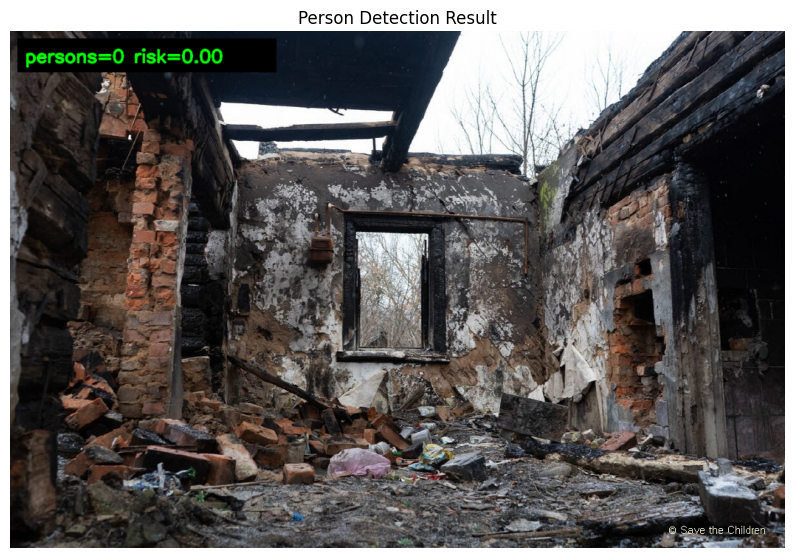

In [14]:
IMAGE_PATH = "test.jpg"  # 여기를 바꿔라

img_path = Path(IMAGE_PATH)

if not img_path.exists():
    print(f"이미지 파일이 없음: {img_path.resolve()}")
    print("IMAGE_PATH를 실제 이미지 경로로 바꾼 뒤 다시 실행.")
else:
    frame = cv2.imread(str(img_path))
    out = detect_people_bgr(frame, model)

    print("person_count:", out["person_count"])
    print("detected:", out["detected"])
    print("risk:", out["risk"])
    print("largest_area_ratio:", out["largest_area_ratio"])
    print("boxes:")
    display(pd.DataFrame(out["boxes"]))

    show_bgr(out["annotated"], title="Person Detection Result")

## 8. 결과 이미지 저장

In [15]:
SAVE_PATH = "person_detect_result.jpg"

if "out" in globals() and out is not None and "annotated" in out:
    cv2.imwrite(SAVE_PATH, out["annotated"])
    print("saved:", Path(SAVE_PATH).resolve())
else:
    print("먼저 이미지 1장 테스트 셀을 실행해야 함.")

saved: /home/bomin/Desktop/ROS2_Project/person_detect_result.jpg


## 9. 폴더 단위 배치 테스트

폴더 안의 이미지들을 전부 검사해서 사람 수와 위험도를 CSV로 저장한다.

In [16]:
IMAGE_DIR = "images"  # 테스트 이미지 폴더
OUTPUT_DIR = Path("person_detect_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_dir = Path(IMAGE_DIR)
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

if not image_dir.exists():
    print(f"이미지 폴더가 없음: {image_dir.resolve()}")
else:
    image_files = [p for p in image_dir.rglob("*") if p.suffix.lower() in image_exts]
    print("num_images:", len(image_files))

    for p in image_files:
        frame = cv2.imread(str(p))
        if frame is None:
            continue

        out = detect_people_bgr(frame, model)
        save_name = OUTPUT_DIR / f"{p.stem}_person.jpg"
        cv2.imwrite(str(save_name), out["annotated"])

        records.append({
            "file": str(p),
            "person_count": out["person_count"],
            "detected": out["detected"],
            "risk": out["risk"],
            "largest_area_ratio": out["largest_area_ratio"],
            "output": str(save_name),
        })

    df = pd.DataFrame(records)
    display(df)

    csv_path = OUTPUT_DIR / "person_detection_summary.csv"
    df.to_csv(csv_path, index=False)
    print("csv saved:", csv_path.resolve())

이미지 폴더가 없음: /home/bomin/Desktop/ROS2_Project/images


## 10. 웹캠 / 카메라 실시간 테스트

기본값은 `/dev/video0`이다.

```python
VIDEO_SOURCE = 0
```

USB 카메라가 여러 개면 `1`, `2`로 바꿔본다.

RTSP/HTTP 스트림이면 문자열 URL을 넣을 수도 있다.

```python
VIDEO_SOURCE = "http://192.168.x.x:5000/video"
```

종료는 OpenCV 창에서 `q` 키.

In [21]:
VIDEO_SOURCE = 0
CAMERA_CONF_THRESHOLD = 0.35
CAMERA_MAX_FRAMES = 0   # 0이면 무제한
FRAME_SKIP = 2          # 2면 2프레임 중 1번만 YOLO 추론

cap = cv2.VideoCapture(VIDEO_SOURCE)

if not cap.isOpened():
    print("카메라를 열 수 없음:", VIDEO_SOURCE)
else:
    frame_idx = 0
    last_annotated = None

    while True:
        ret, frame = cap.read()
        if not ret:
            print("frame read failed")
            break

        frame_idx += 1

        if frame_idx % FRAME_SKIP == 0 or last_annotated is None:
            out = detect_people_bgr(
                frame,
                model,
                conf_threshold=CAMERA_CONF_THRESHOLD,
            )
            last_annotated = out["annotated"]

            print(
                f"\rframe={frame_idx} "
                f"persons={out['person_count']} "
                f"risk={out['risk']:.3f} "
                f"largest_area={out['largest_area_ratio']:.4f}",
                end=""
            )

        cv2.imshow("YOLO person detector", last_annotated)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break

        if CAMERA_MAX_FRAMES > 0 and frame_idx >= CAMERA_MAX_FRAMES:
            break

    cap.release()
    cv2.destroyAllWindows()
    print("\ndone")

frame=1 persons=0 risk=0.000 largest_area=0.0000

QFontDatabase: Cannot find font directory /home/bomin/venv/ros2/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bomin/venv/ros2/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bomin/venv/ros2/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bomin/venv/ros2/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bomin/venv/ros2/lib/python3.

frame=8402 persons=0 risk=0.000 largest_area=0.0000
done


## 11. 웹캠에서 스냅샷 1장만 테스트

OpenCV 창이 잘 안 뜨는 환경이면 이 셀로 한 프레임만 캡처해서 Jupyter 안에 표시한다.

In [18]:
VIDEO_SOURCE = 0

cap = cv2.VideoCapture(VIDEO_SOURCE)

if not cap.isOpened():
    print("카메라를 열 수 없음:", VIDEO_SOURCE)
else:
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("프레임을 읽지 못함.")
    else:
        out = detect_people_bgr(frame, model)
        print("person_count:", out["person_count"])
        print("detected:", out["detected"])
        print("risk:", out["risk"])
        display(pd.DataFrame(out["boxes"]))
        show_bgr(out["annotated"], title="Webcam Snapshot Person Detection")

카메라를 열 수 없음: 0


[ WARN:0@174.169] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@174.169] global cap.cpp:438 open VIDEOIO(FFMPEG): raised OpenCV exception:

OpenCV(4.13.0) /io/opencv/modules/videoio/src/cap_ffmpeg_impl.hpp:1220: error: (-2:Unspecified error) in function 'bool CvCapture_FFMPEG::open(const char*, int, const cv::Ptr<cv::IStreamReader>&, const cv::VideoCaptureParameters&)'
> VIDEOIO/FFMPEG: Camera index out of range (expected: 'index < device_list->nb_devices'), where
>     'index' is 0
> must be less than
>     'device_list->nb_devices' is 0


[ERROR:0@174.169] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


## 12. 튜닝 포인트

### 사람이 잘 안 잡힐 때

```python
CONF_THRESHOLD = 0.20
IMGSZ = 960
```

- `conf_threshold`를 낮추면 더 많이 잡지만 오탐이 늘어난다.
- `imgsz`를 키우면 작은 사람을 더 잘 잡을 수 있지만 느려진다.

### 너무 느릴 때

```python
MODEL_PATH = "yolo11n.pt"
IMGSZ = 416
FRAME_SKIP = 3
DEVICE = "cpu"
```

또는 CUDA 가능하면:

```python
DEVICE = 0
```

### 오탐이 많을 때

```python
CONF_THRESHOLD = 0.50
IOU_THRESHOLD = 0.50
```

### 실내 로봇용 추천 시작값

```python
MODEL_PATH = "yolo11n.pt"
CONF_THRESHOLD = 0.35
IOU_THRESHOLD = 0.45
IMGSZ = 640
FRAME_SKIP = 2
```

## 13. ROS2 노드로 옮길 때 사용할 값

이 노트북에서 검증된 핵심 출력은 ROS2에서 그대로 topic으로 publish하면 된다.

```text
person_count         -> std_msgs/Int32
detected             -> std_msgs/Bool
risk                 -> std_msgs/Float32
boxes                -> Float32MultiArray or vision_msgs/Detection2DArray
annotated image      -> sensor_msgs/Image
```

ROS2 노드에서는 이 함수 구조만 그대로 가져가면 된다.

```python
out = detect_people_bgr(frame_bgr, model)
person_count = out["person_count"]
risk = out["risk"]
boxes = out["boxes"]
overlay = out["annotated"]
```

## 12. 웹캠 실시간 사람 탐지 (OpenCV 창)

아래 셀을 실행하면 카메라 화면에 사람 박스와 사람 수가 함께 표시된다.

- 종료: `q`
- 카메라 번호 변경: `VIDEO_SOURCE = 0` 값을 `1`, `2` 등으로 변경

In [19]:
# 카메라 인덱스 자동 탐색 (Linux 기준)
# 실행해서 열리는 인덱스를 확인한 뒤 VIDEO_SOURCE에 넣으면 됨.

available = []
for i in range(6):
    cap = cv2.VideoCapture(i, cv2.CAP_V4L2)
    ok, _ = cap.read()
    if cap.isOpened() and ok:
        available.append(i)
    cap.release()

print("사용 가능한 카메라 인덱스:", available)
if not available:
    print("카메라가 안 잡힙니다. USB 연결/권한/WSL/컨테이너 장치 전달을 확인하세요.")

사용 가능한 카메라 인덱스: []
카메라가 안 잡힙니다. USB 연결/권한/WSL/컨테이너 장치 전달을 확인하세요.


[ WARN:0@174.174] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@174.174] global cap.cpp:478 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
[ WARN:0@174.174] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ WARN:0@174.174] global cap.cpp:478 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
[ WARN:0@174.174] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video2): can't open camera by index
[ WARN:0@174.174] global cap.cpp:478 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
[ WARN:0@174.174] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video3): can't open camera by index
[ WARN:0@174.174] global cap.cpp:478 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
[ WARN:0@174.174] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video4): can't open camera by in

In [20]:
# 필수 전제: 위에서 import/model/detect_people_bgr 셀을 먼저 실행해야 함
# (아직 실행 안 했다면 아래 보완 코드가 자동으로 처리)

try:
    model  # noqa: F821
except NameError:
    from ultralytics import YOLO
    MODEL_PATH = "yolo11n.pt"
    model = YOLO(MODEL_PATH)

if "detect_people_bgr" not in globals():
    raise RuntimeError("detect_people_bgr 함수가 없습니다. 위의 함수 정의 셀을 먼저 실행하세요.")

VIDEO_SOURCE = 0
CAMERA_CONF_THRESHOLD = 0.35
CAMERA_MAX_FRAMES = 0   # 0이면 무제한
FRAME_SKIP = 2          # 2면 2프레임 중 1번만 추론

cap = cv2.VideoCapture(VIDEO_SOURCE)

if not cap.isOpened():
    print("카메라를 열 수 없음:", VIDEO_SOURCE)
else:
    frame_idx = 0
    last_annotated = None

    while True:
        ret, frame = cap.read()
        if not ret:
            print("frame read failed")
            break

        frame_idx += 1

        if frame_idx % FRAME_SKIP == 0 or last_annotated is None:
            out = detect_people_bgr(
                frame,
                model,
                conf_threshold=CAMERA_CONF_THRESHOLD,
            )
            last_annotated = out["annotated"]

            # 오버레이를 더 크게 넣어서 사람 수를 눈에 잘 띄게 표시
            count_text = f"Person Count: {out['person_count']}"
            cv2.rectangle(last_annotated, (10, 60), (390, 110), (0, 0, 0), -1)
            cv2.putText(
                last_annotated,
                count_text,
                (20, 95),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 255, 255),
                2,
                cv2.LINE_AA,
            )

        cv2.imshow("Webcam Person Detection", last_annotated)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break

        if CAMERA_MAX_FRAMES > 0 and frame_idx >= CAMERA_MAX_FRAMES:
            break

    cap.release()
    cv2.destroyAllWindows()
    print("done")

카메라를 열 수 없음: 0


[ WARN:0@174.182] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@174.182] global cap.cpp:438 open VIDEOIO(FFMPEG): raised OpenCV exception:

OpenCV(4.13.0) /io/opencv/modules/videoio/src/cap_ffmpeg_impl.hpp:1220: error: (-2:Unspecified error) in function 'bool CvCapture_FFMPEG::open(const char*, int, const cv::Ptr<cv::IStreamReader>&, const cv::VideoCaptureParameters&)'
> VIDEOIO/FFMPEG: Camera index out of range (expected: 'index < device_list->nb_devices'), where
>     'index' is 0
> must be less than
>     'device_list->nb_devices' is 0


[ERROR:0@174.182] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
